### Example Calibration with Known Functional Form - Friedman function
In this example, we calibrate the Friedman function, where one of the inputs is treated as a functional variable and there is no discrepancy.  This is a difficult calibration problem because, for any response, there are many combinations of inputs that produce equally good simulations.

#%pip install ../.

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import impala.superCal.post_process as pp
from impala import superCal as sc

This is the Friedman function, where one of the inputs is functional in tt as follows. For this calibration, we will assume that the functional form f(x) is known. 

In [2]:
def f(x):
    out = (
        10.0 * np.sin(np.pi * tt * x[0])
        + 20.0 * (x[1] - 0.5) ** 2
        + 10 * x[2]
        + 5.0 * x[3]
    )
    return out

Here, we generate some realizations from f, including 200 "prior simulations" and one simulation with noise that we will treat as our observations.  Note that we use 9 variables while f only uses 4, so we have 5 inert variables.

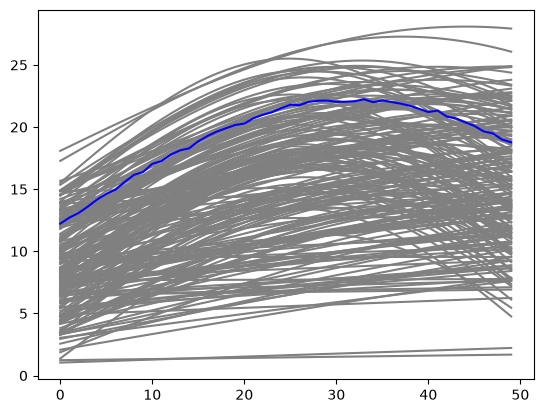

In [3]:
p = 9
nt = 50
tt = np.linspace(0, 1, nt)

xx_true = np.random.default_rng(42).random((1, p))
yobs = (
    np.apply_along_axis(f, 1, xx_true).reshape(nt)
    + np.random.default_rng(4567).normal(size=50) * 0.1
)

x_prior = np.random.default_rng(234).random((200, p))
y_sim_prior = np.apply_along_axis(f, 1, x_prior)
plt.plot(y_sim_prior.T, color="grey", label="prior")
plt.plot(yobs, color="blue", label="obs")

Now we are ready to set up and run our calibration. Since the functional form of f(x) is assumed known and fast to compute, we specify the model to calibrate using the **ModelF** class.

In [4]:
input_names = [str(v) for v in list(range(p))]  # list of input names
bounds = dict(
    zip(input_names, np.concatenate((np.zeros((p, 1)), np.ones((p, 1))), 1))
)  # bounds for each input

setup = sc.CalibSetup(
    bounds, constraint_func="bounds"
)  # initialize with the only constraints being the bounds
model = sc.ModelF(
    f, input_names
)  # put f into the right structure; this could be replaced with an emulator
setup.addVecExperiments(
    yobs=yobs,  # observation vector
    model=model,  # model that predicts a vector
    sd_est=[
        1.0
    ],  # yobs error estimate (possibly a vector of estimates for different parts of yobs vector)
    s2_df=[
        0
    ],  # yobs error degrees of freedom (larger means more confidence in sd_est), same shape as sd_est
    s2_ind=[0] * nt,
)  # if sd_est is a vector of length 3, this is a vector of length len(yobs) with
# values (0, 1, 2) indicating which sd_est corresponds to which part of yobs

# Note: if you have multiple experiments, just call setup.addVecExperiments multiple times
setup.setTemperatureLadder(
    1.05 ** np.arange(40)
)  # temperature ladder, typically (1 + step)**np.arange(ntemps)
setup.setMCMC(
    nmcmc=15000, decor=100
)  # MCMC number of iterations, and how often to take a decorrelation step
# out = sc.calibPool(setup)  # pooled calibration, impala version 1
out = sc.calibPool_v2(setup)  # pooled calibration, impala version 2

[2026-06-24 08:49:17 | 14999/14999 (100%) | WALL: 0:00:49 | ETA: 0:00:00 | 302.00it/s]
Calibration MCMC Complete. Time: 49.679585 seconds.


We can look at trace plots of the calibration parameters (theta).  We want these to look like they converge, and choose which MCMC iterations to use accordingly. Convergence can sometimes be difficult to assess by eye, but we want these plots to look somewhat like fuzzy caterpillars that are lying totally flat. We will exclude any iterations at the start of the chain that don't exhibit this property. 

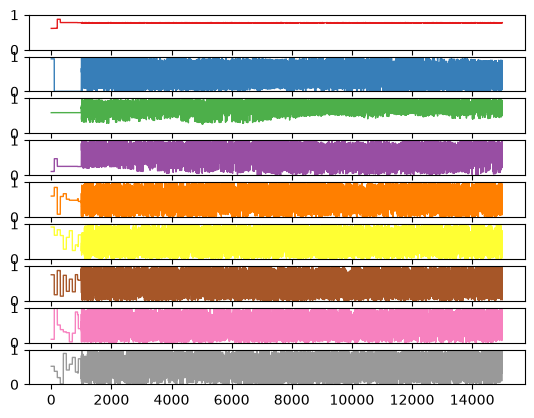

In [5]:
pp.parameter_trace_plot(out.theta[:, 0], ylim=[0, 1])

We disregard the first 5000 iterations and use every other iteration after that, which leaves us with 5000 iterations from our original 15000.  Here is the pairs plot of the calibration parameters' posterior (theta). 

Note how the posterior distributions for parameters 3-7 appear uniform across (0,1). These parameters are not identified, and this is to be expected. The strange posterior surface of the Friedman function is evident in the scatterplot for draws of parameters 1 and 2, which exhibits an arch-like features. Because IMPALA uses a sophisticated MCMC sampling scheme for parameter estimation, it is able to navigate this complicated posterior surface and produce sensible results. 

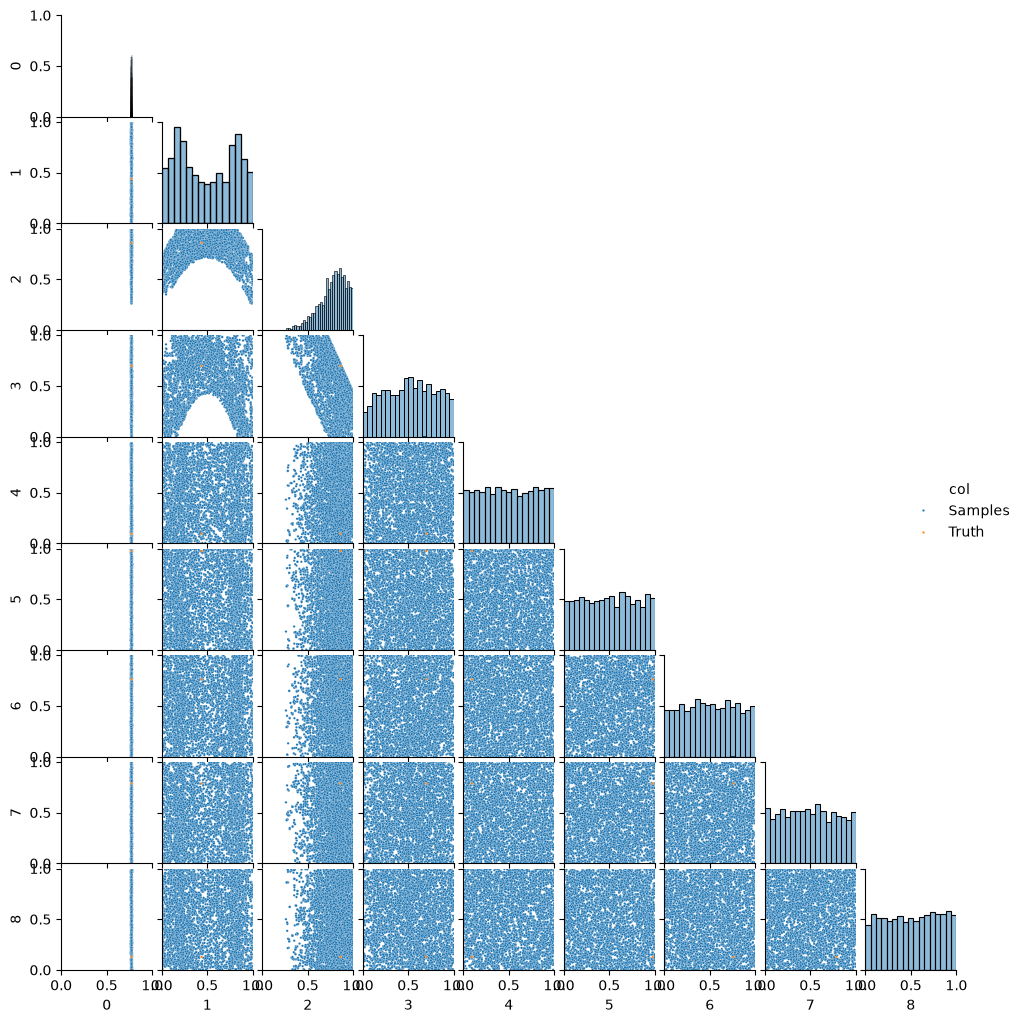

In [17]:
mcmc_use = np.arange(5000, 15000, 2)  # burn and thin index
mat_theta_xxtrue = np.vstack((
    out.theta[mcmc_use, 0],
    sc.normalize(xx_true, setup.bounds_mat),
))
col = ["Samples"] * len(mcmc_use) + ["Truth"]  # color
s = 3  # size

pp.pairs(setup, mat_theta_xxtrue, col, s)

We also give the trace plot of the error variance (with the true values).

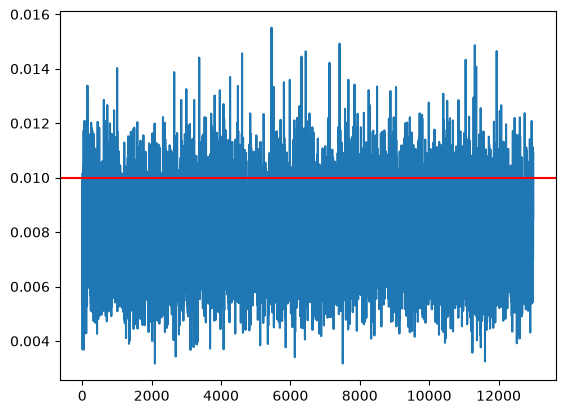

In [18]:
plt.plot(out.s2[0][2000:, 0])
plt.axhline(0.01, color="r")

Let's produce our calibrated posterior predictions (with and without the observation error) with the observational data.

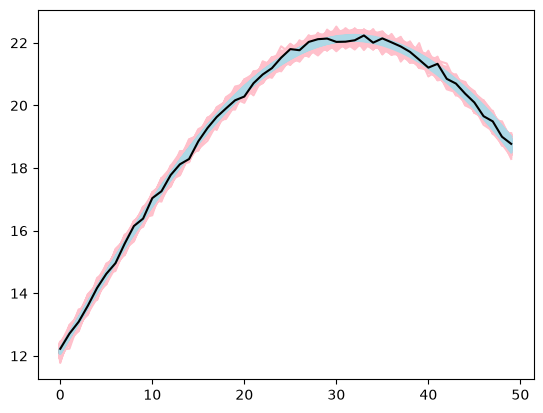

In [19]:
mat = np.array(list(out.theta_native.values())).T[mcmc_use]
pred = np.apply_along_axis(f, 1, mat).reshape(len(mcmc_use), nt)
pred_s2 = np.random.normal(size=(len(mcmc_use), nt)) * np.sqrt(
    out.s2[0][mcmc_use, 0]
)
plt.plot(
    (pred + pred_s2).T, color="pink"
)  # posterior predictions including noise
plt.plot(
    pred.T, color="lightblue"
)  # posterior predictions of noiseless function
plt.plot(yobs, color="black")  # observations

Now, suppose we want to obtain a single set of parameter estimates that best agree with out observed data. Several reasonable approaches exist, but here we identify the posterior draw of theta with the smallest squared prediction error.

In [20]:
pred_sse = np.sum(
    (pred - np.repeat(setup.ys[0].reshape(1, -1), len(mcmc_use), axis=0)) ** 2,
    axis=1,
)
theta_minsse = mat[np.where(pred_sse == pred_sse.min())[0][0], :]

Now, let's add the "best" predictions to the former plot. 

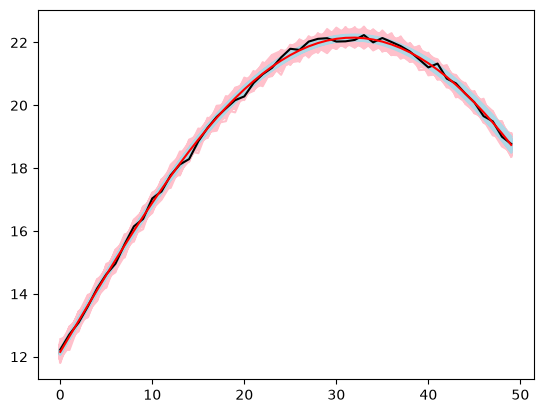

In [21]:
mat = np.array(list(out.theta_native.values())).T[mcmc_use]
pred = np.apply_along_axis(f, 1, mat).reshape(len(mcmc_use), nt)
pred_s2 = np.random.normal(size=(len(mcmc_use), nt)) * np.sqrt(
    out.s2[0][mcmc_use, 0]
)
plt.plot(
    (pred + pred_s2).T, color="pink"
)  # posterior predictions including noise
plt.plot(
    pred.T, color="lightblue"
)  # posterior predictions of noiseless function
plt.plot(yobs, color="black")  # observations
plt.plot(
    pred[np.where(pred_sse == pred_sse.min())[0][0], :], color="red"
)  # observations
plt.show()

# Hierarchical Demonstration

Now, we will demonstrate using the same Friedman function simulation scenario but this time calibrating the parameters separately for three experiments, although the truth in this case will be that there is a shared parameterization and different amounts of noise.

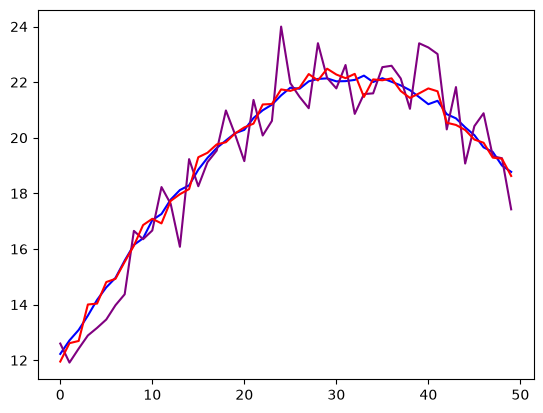

In [4]:
p = 9
nt = 50
tt = np.linspace(0, 1, nt)

yobs_1 = (
    np.apply_along_axis(f, 1, xx_true).reshape(nt)
    + np.random.default_rng(4567).normal(size=50) * 0.1
)
yobs_2 = (
    np.apply_along_axis(f, 1, xx_true).reshape(nt)
    + np.random.default_rng(5677).normal(size=50) * 1
)
yobs_3 = (
    np.apply_along_axis(f, 1, xx_true).reshape(nt)
    + np.random.default_rng(54352).normal(size=50) * 0.3
)


plt.plot(yobs_1, color="blue", label="Experiment 1")
plt.plot(yobs_2, color="purple", label="Experiment 2")
plt.plot(yobs_3, color="red", label="Experiment 3")

Now, we define the function evaluation for the stacked experiments, so now tt needs to be three times as long

In [5]:
tt_long = np.append(np.append(tt, tt), tt)


def f_vec(tt, x):
    out = (
        10.0 * np.sin(np.pi * tt * x[0])
        + 20.0 * (x[1] - 0.5) ** 2
        + 10 * x[2]
        + 5.0 * x[3]
    )
    return out


def f_hier(x):
    x = x.reshape(-1, p)
    inputs = np.vstack([f_vec(tt_long, x0) for x0 in x])
    res = np.vstack(inputs)
    return res

In [ ]:
input_names = [str(v) for v in list(range(p))]  # list of input names
bounds = dict(
    zip(input_names, np.concatenate((np.zeros((p, 1)), np.ones((p, 1))), 1))
)  # bounds for each input
# This defines the different experiments
s2_inds = np.stack([
    np.repeat(0, len(yobs)),
    np.repeat(1, len(yobs)),
    np.repeat(2, len(yobs)),
]).flatten()
yobs_long = np.stack([yobs_1, yobs_2, yobs_3]).flatten()

setup = sc.CalibSetup(
    bounds, constraint_func="bounds"
)  # initialize with the only constraints being the bounds
model = sc.ModelF_v2(
    f_hier, input_names, exp_ind=s2_inds
)  # put f into the right structure; this could be replaced with an emulator. _v2 indicates an updated version of ModelF that is better suited for hierarchical models

setup.addVecExperiments(
    yobs=yobs_long,  # observation vector
    model=model,  # model that predicts a vector
    sd_est=[
        1.0,
        1.0,
        1.0,
    ],  # yobs error estimate (possibly a vector of estimates for different parts of yobs vector)
    s2_df=[
        0,
        0,
        0,
    ],  # yobs error degrees of freedom (larger means more confidence in sd_est), same shape as sd_est
    s2_ind=s2_inds,
    theta_ind=s2_inds,
)  # if sd_est is a vector of length 3, this is a vector of length len(yobs) with
# values (0, 1, 2) indicating which sd_est corresponds to which part of yobs

# Note: if you have multiple experiments, just call setup.addVecExperiments multiple times
setup.setTemperatureLadder(
    1.05 ** np.arange(40)
)  # temperature ladder, typically (1 + step)**np.arange(ntemps)
setup.setMCMC(
    nmcmc=15000, decor=100
)  # MCMC number of iterations, and how often to take a decorrelation step
setup.setHierPriors(
    theta0_prior_mean=np.repeat(0.5, setup.p),  # prior mean for theta_0 values
    theta0_prior_cov=np.eye(setup.p)
    * 10**2,  # prior covariances for theta_0 values
    Sigma0_prior_df=setup.p
    + 20,  # degrees of freedom for Inverse Wishart prior for Sigma_0. Generally, larger values indicate greater borrowing across experiments.
    Sigma0_prior_scale=np.eye(setup.p)
    * 0.1
    ** 2,  # scale for Inverse Wishart prior for Sigma_0. Generally, larger values indicate greater borrowing across experiments.
)
# out_hier = sc.calibHier(setup)  #impala version 1
out_hier = sc.calibHier_v2(setup)  # impala version 2

In terms of predicting behavior for new experiments, the distribution we are interested in is the N(theta_0, Sigma_0) distribution describing theta_e values for observed and new experiments. We generate draws from this distribution (we will call this the "parent" distribution) as follows:

In [9]:
theta_parent = sc.chol_sample_1per_constraints(
    out_hier.theta0[:, 0],
    out_hier.Sigma0[:, 0],
    setup.checkConstraints,
    setup.bounds_mat,
    setup.bounds.keys(),
    setup.bounds,
    setup.constants,
)

And here is a trace plot for those parent distribution draws. We can see a lot more correlation along the chain, so we might lean toward running the chain longer! 

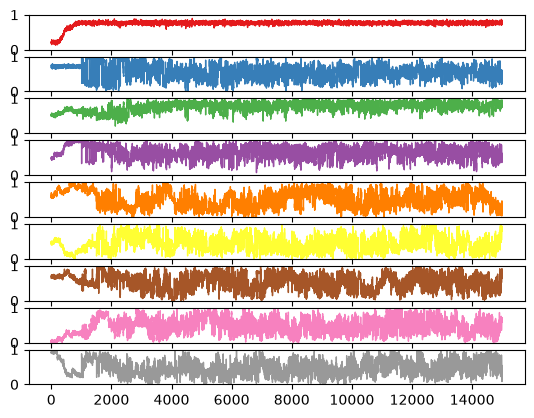

In [10]:
pp.parameter_trace_plot(theta_parent, ylim=[0, 1])

And here is a pairs plot. 

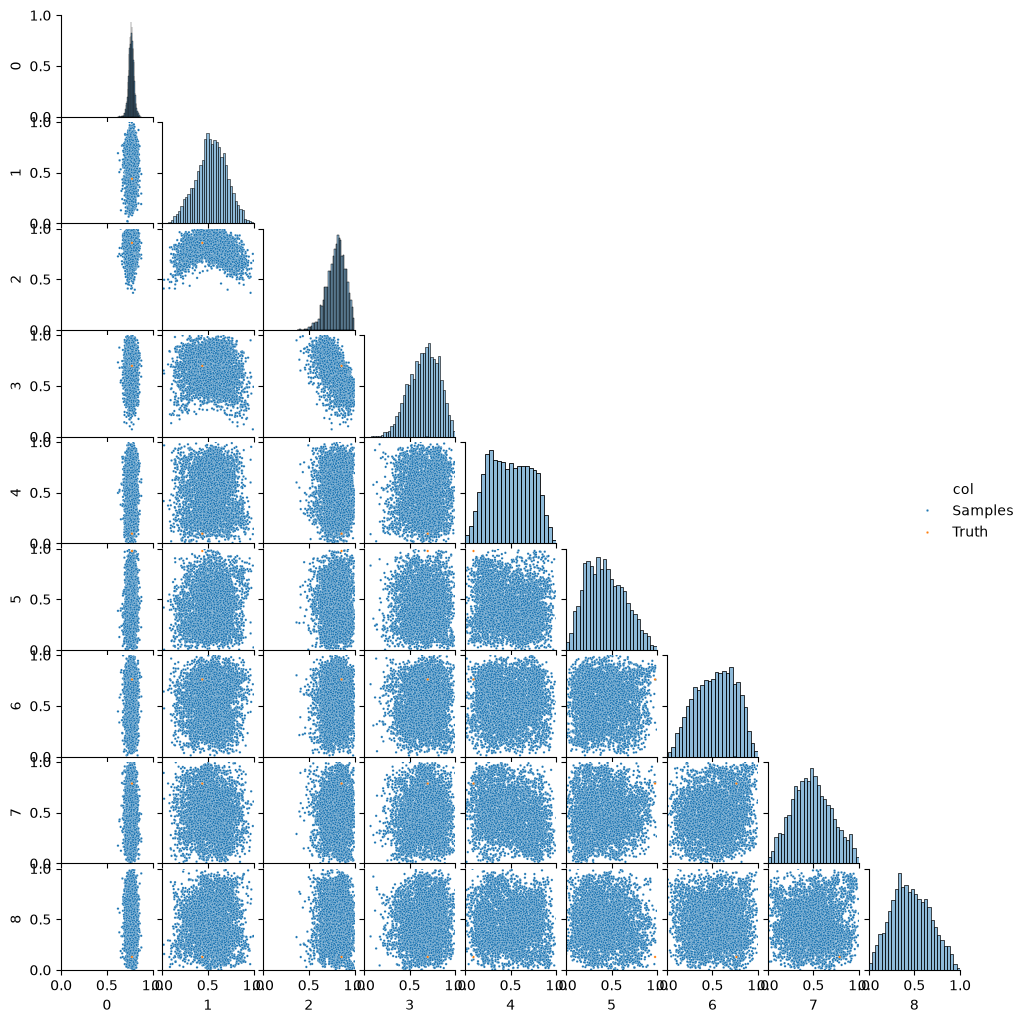

In [11]:
mcmc_use = np.arange(5000, 15000, 2)  # burn and thin index
mat_theta_xxtrue = np.vstack((
    theta_parent[mcmc_use, :],
    sc.normalize(xx_true, setup.bounds_mat),
))
col = ["Samples"] * len(mcmc_use) + ["Truth"]  # color
s = 3  # size

pp.pairs(setup, mat_theta_xxtrue, col, s)

We are able to recover the experiment-specific measurement errors. 

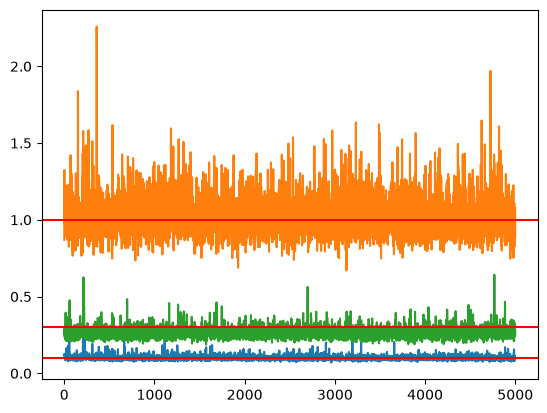

In [12]:
plt.plot(np.sqrt(out_hier.s2[0][mcmc_use, 0]))
plt.axhline(0.1, color="r")
plt.axhline(1, color="r")
plt.axhline(0.3, color="r")

And here we show experiment-specific parameters. 

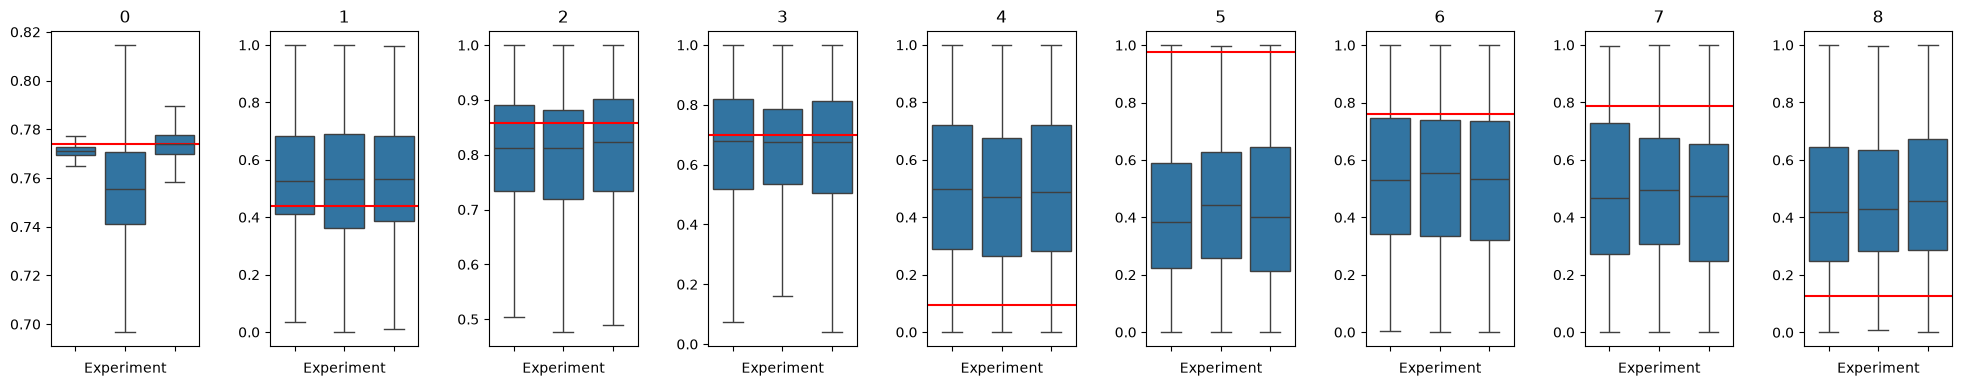

In [ ]:
theta_exp = [out_hier.theta[0][:, 0, j, :] for j in range(3)]

KEYS = np.array(pd.DataFrame(setup.bounds.keys())).flatten()
theta_i = []
for j in range(len(theta_exp)):
    mat = pd.DataFrame(
        np.array(
            pd.DataFrame(
                sc.tran_unif(
                    theta_exp[j][mcmc_use, :],
                    setup.bounds_mat,
                    setup.bounds.keys(),
                ).values()
            )
        ).T,
        columns=KEYS,
    )
    mat["exp"] = j
    if j == 0:
        theta_i = [mat]
    else:
        theta_i.append(mat)
theta_i_long = pd.concat(theta_i)

fig, ax = plt.subplots(1, setup.p, figsize=(20, 4))
fig.tight_layout(pad=2.0)
for j in range(setup.p):
    ax[j].set_xlabel("Experiment")
    ax[j].set_ylabel("")
    ax[j].set_title(KEYS[j])
    A = sns.boxplot(
        data=theta_i_long,
        x=theta_i_long["exp"],
        y=theta_i_long[KEYS[j]],
        ax=ax[j],
        showfliers=False,
    )
    A.set(xlabel="Experiment", ylabel="")
    A.set(xticklabels=[])
    ax[j].axhline(y=xx_true.flatten()[j], c="red")

# Hierarchical with different measurement errors and shared theta for first two curves

In [25]:
input_names = [str(v) for v in list(range(p))]  # list of input names
bounds = dict(
    zip(input_names, np.concatenate((np.zeros((p, 1)), np.ones((p, 1))), 1))
)  # bounds for each input
# This defines the different experiments
s2_inds = np.stack([
    np.repeat(0, len(yobs)),
    np.repeat(1, len(yobs)),
    np.repeat(2, len(yobs)),
]).flatten()
yobs_long = np.stack([yobs_1, yobs_2, yobs_3]).flatten()
theta_inds = np.stack([
    np.repeat(0, len(yobs)),
    np.repeat(0, len(yobs)),
    np.repeat(1, len(yobs)),
]).flatten()

setup = sc.CalibSetup(
    bounds, constraint_func="bounds"
)  # initialize with the only constraints being the bounds
model = sc.ModelF_v2(
    f_hier, input_names, exp_ind=theta_inds
)  # put f into the right structure; this could be replaced with an emulator. _v2 indicates an updated version of ModelF that is better suited for hierarchical models

setup.addVecExperiments(
    yobs=yobs_long,  # observation vector
    model=model,  # model that predicts a vector
    sd_est=[
        1.0,
        1.0,
        1.0,
    ],  # yobs error estimate (possibly a vector of estimates for different parts of yobs vector)
    s2_df=[
        0,
        0,
        0,
    ],  # yobs error degrees of freedom (larger means more confidence in sd_est), same shape as sd_est
    s2_ind=s2_inds,
    theta_ind=theta_inds,
)  # if sd_est is a vector of length 3, this is a vector of length len(yobs) with
# values (0, 1, 2) indicating which sd_est corresponds to which part of yobs

# Note: if you have multiple experiments, just call setup.addVecExperiments multiple times
setup.setTemperatureLadder(
    1.05 ** np.arange(40)
)  # temperature ladder, typically (1 + step)**np.arange(ntemps)
setup.setMCMC(
    nmcmc=15000, decor=100
)  # MCMC number of iterations, and how often to take a decorrelation step
setup.setHierPriors(
    theta0_prior_mean=np.repeat(0.5, setup.p),  # prior mean for theta_0 values
    theta0_prior_cov=np.eye(setup.p)
    * 10**2,  # prior covariances for theta_0 values
    Sigma0_prior_df=setup.p
    + 20,  # degrees of freedom for Inverse Wishart prior for Sigma_0. Generally, larger values indicate greater borrowing across experiments.
    Sigma0_prior_scale=np.eye(setup.p)
    * 0.1
    ** 2,  # scale for Inverse Wishart prior for Sigma_0. Generally, larger values indicate greater borrowing across experiments.
)
out_hier = sc.calibHier_v2(
    setup
)  # impala version 2 only (not able to be implemented in impala version 1)

[2026-06-22 16:15:56 | 14999/14999 (100%) | WALL: 0:04:24 | ETA: 0:00:00 | 56.62it/s]
Calibration MCMC Complete. Time: 265.183252 seconds.


In [26]:
theta_parent = sc.chol_sample_1per_constraints(
    out_hier.theta0[:, 0],
    out_hier.Sigma0[:, 0],
    setup.checkConstraints,
    setup.bounds_mat,
    setup.bounds.keys(),
    setup.bounds,
    setup.constants,
)

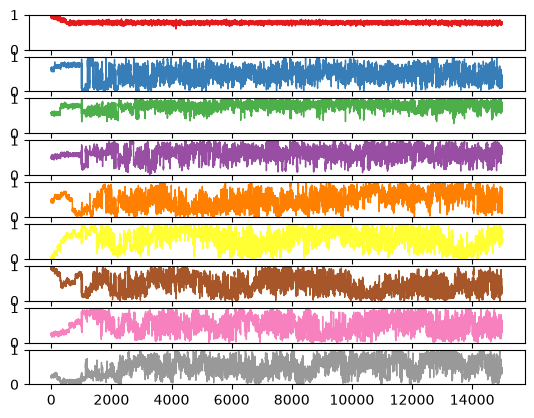

In [27]:
pp.parameter_trace_plot(theta_parent, ylim=[0, 1])

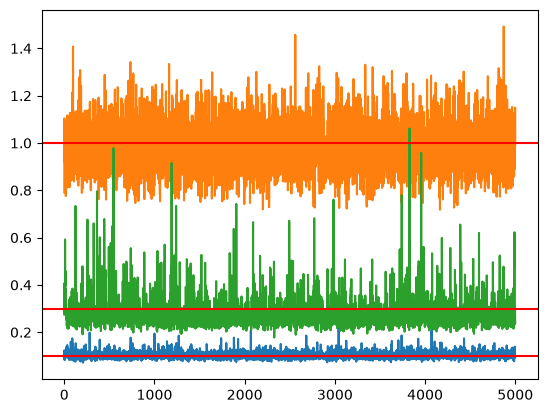

In [28]:
mcmc_use = np.arange(5000, 15000, 2)  # burn and thin index

plt.plot(np.sqrt(out_hier.s2[0][mcmc_use, 0]))
plt.axhline(0.1, color="r")
plt.axhline(1, color="r")
plt.axhline(0.3, color="r")

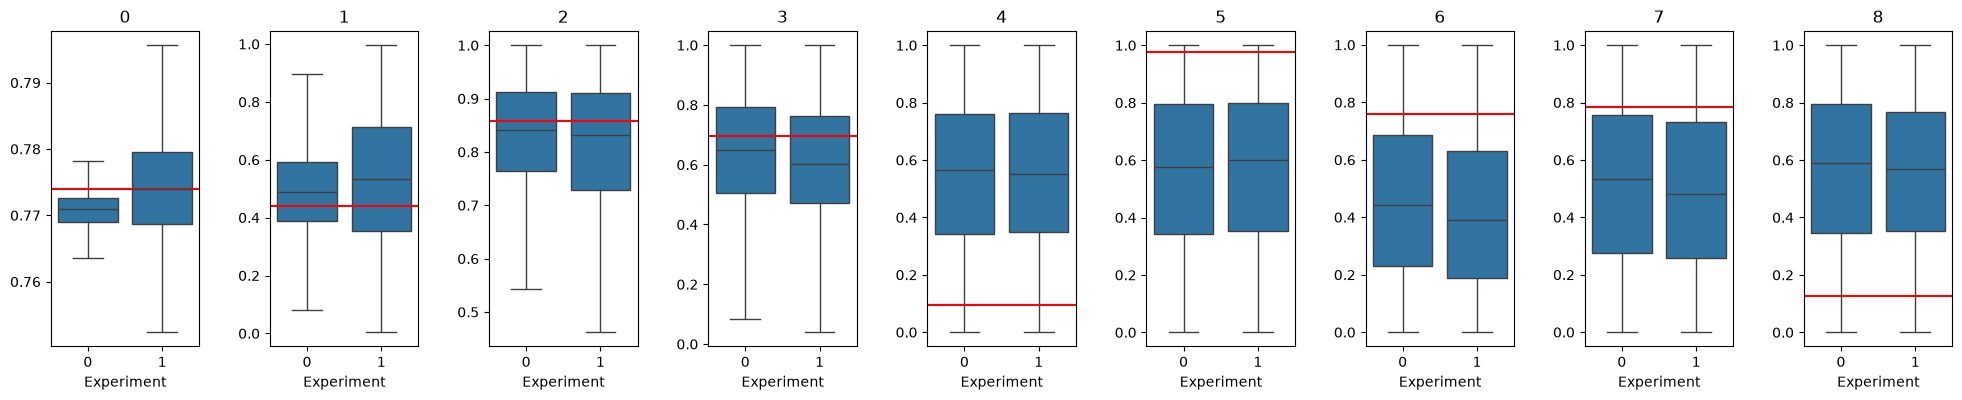

In [ ]:
theta_exp = [out_hier.theta[0][:, 0, j, :] for j in range(2)]

KEYS = np.array(pd.DataFrame(setup.bounds.keys())).flatten()
theta_i = []
for j in range(len(theta_exp)):
    mat = pd.DataFrame(
        np.array(
            pd.DataFrame(
                sc.tran_unif(
                    theta_exp[j][mcmc_use, :],
                    setup.bounds_mat,
                    setup.bounds.keys(),
                ).values()
            )
        ).T,
        columns=KEYS,
    )
    mat["exp"] = j
    if j == 0:
        theta_i = [mat]
    else:
        theta_i.append(mat)
theta_i_long = pd.concat(theta_i)

fig, ax = plt.subplots(1, setup.p, figsize=(20, 4))
fig.tight_layout(pad=2.0)
for j in range(setup.p):
    ax[j].set_xlabel("Experiment")
    ax[j].set_ylabel("")
    ax[j].set_title(KEYS[j])
    A = sns.boxplot(
        data=theta_i_long,
        x=theta_i_long["exp"],
        y=theta_i_long[KEYS[j]],
        ax=ax[j],
        showfliers=False,
    )
    A.set(xlabel="Experiment", ylabel="")
    # A.set(xticklabels=[])
    ax[j].axhline(y=xx_true.flatten()[j], c="red")

# Clustered calibration 

In [32]:
input_names = [str(v) for v in list(range(p))]  # list of input names
bounds = dict(
    zip(input_names, np.concatenate((np.zeros((p, 1)), np.ones((p, 1))), 1))
)  # bounds for each input
# This defines the different experiments
s2_inds = np.stack([
    np.repeat(0, len(yobs)),
    np.repeat(1, len(yobs)),
    np.repeat(2, len(yobs)),
]).flatten()
yobs_long = np.stack([yobs_1, yobs_2, yobs_3]).flatten()

setup = sc.CalibSetup(
    bounds, constraint_func="bounds"
)  # initialize with the only constraints being the bounds
model = sc.ModelF_v2(
    f_hier, input_names, exp_ind=s2_inds
)  # put f into the right structure; this could be replaced with an emulator. _v2 indicates an updated version of ModelF that is better suited for hierarchical models

setup.addVecExperiments(
    yobs=yobs_long,  # observation vector
    model=model,  # model that predicts a vector
    sd_est=[
        1.0,
        1.0,
        1.0,
    ],  # yobs error estimate (possibly a vector of estimates for different parts of yobs vector)
    s2_df=[
        0,
        0,
        0,
    ],  # yobs error degrees of freedom (larger means more confidence in sd_est), same shape as sd_est
    s2_ind=s2_inds,
    theta_ind=s2_inds,
)  # if sd_est is a vector of length 3, this is a vector of length len(yobs) with
# values (0, 1, 2) indicating which sd_est corresponds to which part of yobs

# Note: if you have multiple experiments, just call setup.addVecExperiments multiple times
setup.setTemperatureLadder(
    1.05 ** np.arange(40)
)  # temperature ladder, typically (1 + step)**np.arange(ntemps)
setup.setMCMC(
    nmcmc=15000, decor=100
)  # MCMC number of iterations, and how often to take a decorrelation step
setup.setHierPriors(
    theta0_prior_mean=np.repeat(0.5, setup.p),  # prior mean for theta_0 values
    theta0_prior_cov=np.eye(setup.p)
    * 10**2,  # prior covariances for theta_0 values
    Sigma0_prior_df=setup.p
    + 20,  # degrees of freedom for Inverse Wishart prior for Sigma_0. Generally, larger values indicate greater borrowing across experiments.
    Sigma0_prior_scale=np.eye(setup.p)
    * 0.1
    ** 2,  # scale for Inverse Wishart prior for Sigma_0. Generally, larger values indicate greater borrowing across experiments.
)
setup.setClusterPriors(
    nclustmax=3,  # maximum number of unique clusters allowed. Usually, this can be set equal to the number of experiments.
    eta_prior_shape=1,  # shape parameter for Gamma prior for eta, the "concentration" parameter controlling the propensity for experiments to join existing clusters
    eta_prior_rate=1,  # rate parameter for Gamma prior for eta, the "concentration" parameter controlling the propensity for experiments to join existing clusters
)
# out_clust = sc.calibClust(setup)  #impala version 1
out_clust = sc.calibClust_v2(setup)  # impala version 2

Calibration MCMC Complete. Time: 3721.157356 seconds.


In [34]:
## Organize MCMC Outputs
eta = pd.DataFrame(
    out_clust.eta[:, 0].reshape(-1, 1), columns=["eta"]
)  # concentration parameter draws
delta_exp = [
    out_clust.delta[0][:, 0, j] for j in range(3)
]  # cluster membership draws
omega_g = [
    out_clust.theta[j][0, :, :] for j in range(len(out_clust.theta))
]  # omega_g draws
omega_g = np.asarray(omega_g)
G0_parent = sc.chol_sample_1per_constraints(
    out_clust.theta0[:, 0],
    out_clust.Sigma0[:, 0],
    setup.checkConstraints,
    setup.bounds_mat,
    setup.bounds.keys(),
    setup.bounds,
    setup.constants,
)  # draws from G0
df = pd.DataFrame(G0_parent, columns=setup.bounds.keys())

### Draw from Parent Distribution
A = omega_g  # (niter x nclust x p)
B = np.zeros((
    omega_g.shape[0],
    setup.nclustmax,
))  # membership numbers (niter x nclust)
for i in range(len(delta_exp)):
    for j in range(omega_g.shape[0]):
        B[j, delta_exp[i][j]] += 1
N = B[0, :].sum()  # number of experiments
new_parent_ind = [
    np.random.choice(
        a=np.arange(0, 2),
        size=1,
        p=np.append(
            N / (np.asarray(eta)[j] + N),
            np.asarray(eta)[j] / (np.asarray(eta)[j] + N),
        ),
    )[0]
    for j in range(omega_g.shape[0])
]
theta_parent = [
    A[
        j,
        np.random.choice(
            a=np.arange(0, setup.nclustmax), size=1, p=B[j, :] / (B[j, :].sum())
        )[0],
        :,
    ]
    if new_parent_ind[j] == 0
    else np.asarray(df)[j, :]
    for j in range(omega_g.shape[0])
]
theta_parent = np.asarray(theta_parent)
theta_parent = pd.DataFrame(theta_parent, columns=setup.bounds.keys())

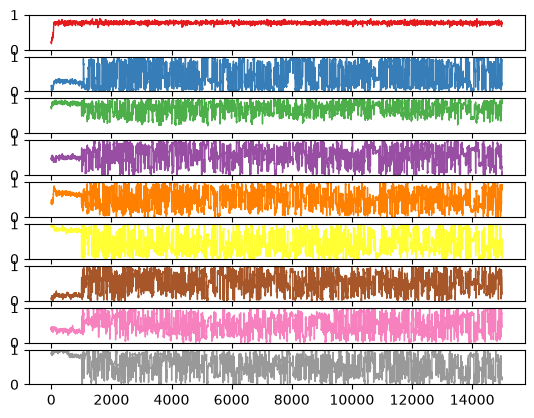

In [37]:
pp.parameter_trace_plot(np.array(theta_parent), ylim=[0, 1])

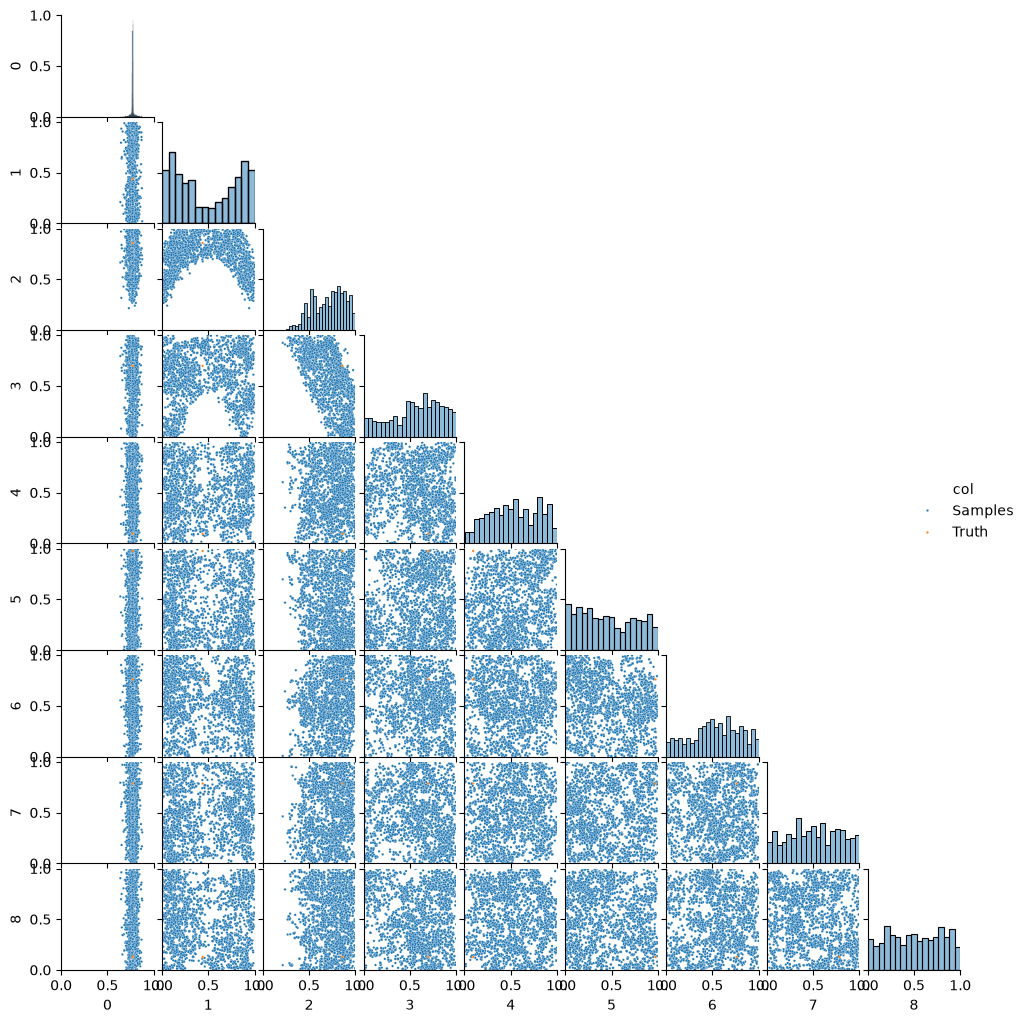

In [39]:
mcmc_use = np.arange(5000, 15000, 2)  # burn and thin index
mat_theta_xxtrue = np.vstack((
    np.array(theta_parent)[mcmc_use, :],
    sc.normalize(xx_true, setup.bounds_mat),
))
col = ["Samples"] * len(mcmc_use) + ["Truth"]  # color
s = 3  # size

pp.pairs(setup, mat_theta_xxtrue, col, s)

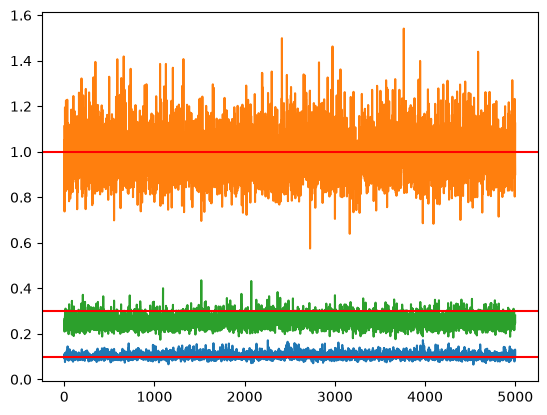

In [41]:
plt.plot(np.sqrt(out_clust.s2[0][mcmc_use, 0]))
plt.axhline(0.1, color="r")
plt.axhline(1, color="r")
plt.axhline(0.3, color="r")

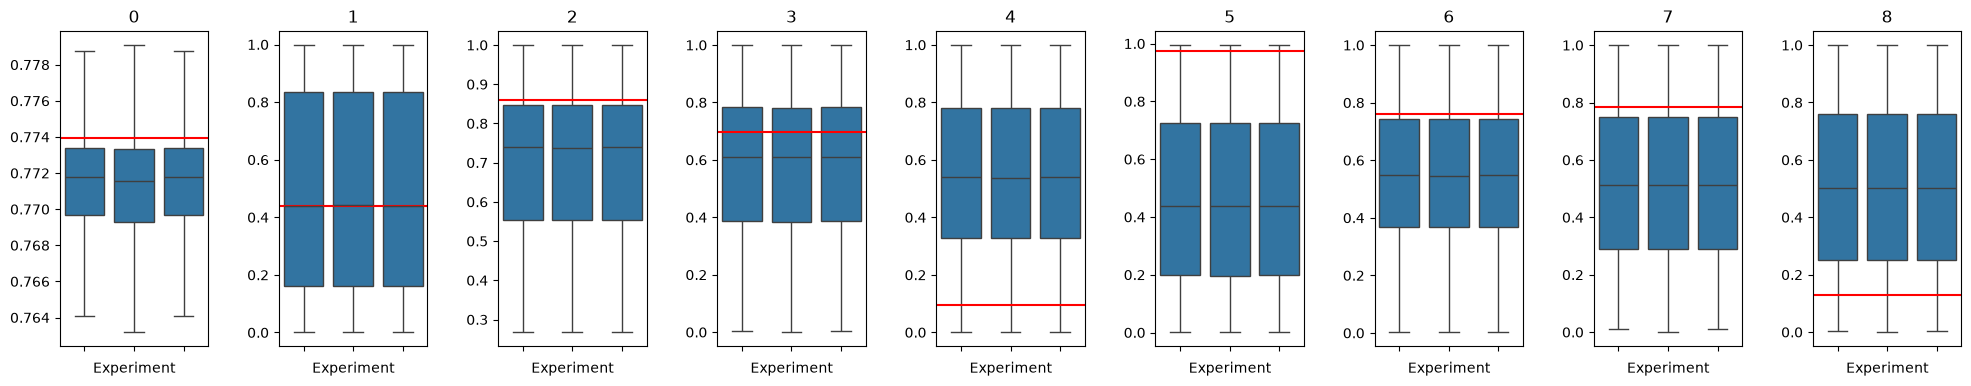

In [ ]:
theta_exp = [out_clust.theta_hist[0][:, 0, j, :] for j in range(3)]

KEYS = np.array(pd.DataFrame(setup.bounds.keys())).flatten()
theta_i = []
for j in range(len(theta_exp)):
    mat = pd.DataFrame(
        np.array(
            pd.DataFrame(
                sc.tran_unif(
                    theta_exp[j][mcmc_use, :],
                    setup.bounds_mat,
                    setup.bounds.keys(),
                ).values()
            )
        ).T,
        columns=KEYS,
    )
    mat["exp"] = j
    if j == 0:
        theta_i = [mat]
    else:
        theta_i.append(mat)
theta_i_long = pd.concat(theta_i)

fig, ax = plt.subplots(1, setup.p, figsize=(20, 4))
fig.tight_layout(pad=2.0)
for j in range(setup.p):
    ax[j].set_xlabel("Experiment")
    ax[j].set_ylabel("")
    ax[j].set_title(KEYS[j])
    A = sns.boxplot(
        data=theta_i_long,
        x=theta_i_long["exp"],
        y=theta_i_long[KEYS[j]],
        ax=ax[j],
        showfliers=False,
    )
    A.set(xlabel="Experiment", ylabel="")
    A.set(xticklabels=[])
    ax[j].axhline(y=xx_true.flatten()[j], c="red")

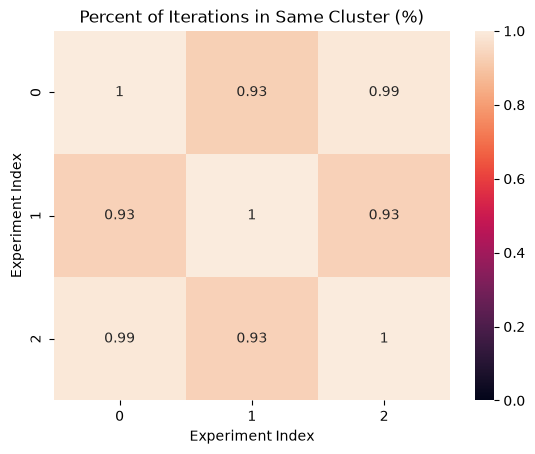

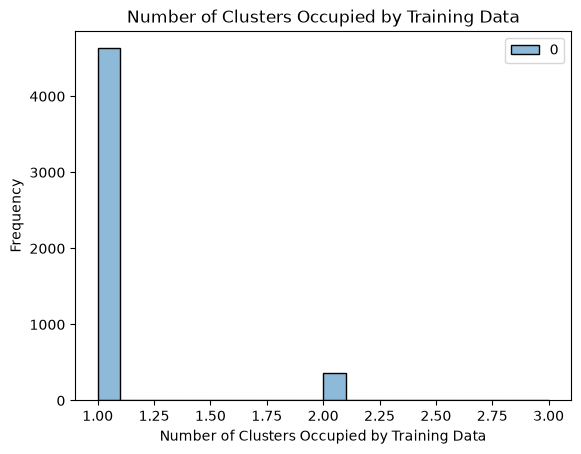

In [ ]:
cluster_draws = np.vstack(delta_exp).T
cluster_draws = cluster_draws[mcmc_use, :]
D = []
for i in range(setup.nclustmax):
    A = [
        np.where(cluster_draws[j, :] == i)[0]
        for j in range(cluster_draws.shape[0])
        if len(np.where(cluster_draws[j, :] == i)[0]) > 1
    ]
    B = [
        np.asarray(list(itertools.combinations(A[j], 2))) for j in range(len(A))
    ]
    D.append(np.concatenate(B, axis=0))
cluster_pairs = np.concatenate(D, axis=0)
co_cluster = np.zeros((3, 3), dtype="int32")
for i in range(cluster_pairs.shape[0]):
    co_cluster[cluster_pairs[i, 0], cluster_pairs[i, 1]] = (
        co_cluster[cluster_pairs[i, 0], cluster_pairs[i, 1]] + 1
    )
    co_cluster[cluster_pairs[i, 1], cluster_pairs[i, 0]] = (
        co_cluster[cluster_pairs[i, 0], cluster_pairs[i, 1]] + 1
    )
co_cluster = co_cluster / cluster_draws.shape[0]
for i in range(3):
    co_cluster[i, i] = 1
ax = sns.heatmap(co_cluster, linewidths=0, vmin=0, vmax=1, annot=True)
ax.set_xlabel("Experiment Index")
ax.set_ylabel("Experiment Index")
ax.set_title("Percent of Iterations in Same Cluster (%)")
plt.show()

num_clust = [
    len(np.unique(cluster_draws[i, :])) for i in range(cluster_draws.shape[0])
]
ax = sns.histplot(pd.DataFrame(num_clust), binwidth=0.1)
ax.set_xlabel("Number of Clusters Occupied by Training Data")
ax.set_ylabel("Frequency")
ax.set_title("Number of Clusters Occupied by Training Data")
plt.show()